# 3. Predicting next day's energy consumption.

## 3.1. Load datasets
Importing, loading datasets and printing datasets

In [46]:
%matplotlib notebook
%matplotlib inline
import numpy as np
import matplotlib.pylab as plt
from scipy.io import loadmat
from scipy.io import savemat
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer, PowerTransformer, MinMaxScaler
from sklearn.model_selection import validation_curve
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from  warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category = ConvergenceWarning)

# Loading the datasets
mat = loadmat("powerTrainData.mat")
X_train = mat["powerTrainInput"][:, :].T
y_train = mat["powerTrainOutput"].reshape(len(X_train))
date_train = mat["powerTrainDate"].T
X_test = mat["powerTestInput"][:, :].T

print("X_train shape: {}".format(X_train.shape))
print("y_train shape: {}".format(y_train.shape))
print("date_train shape: {}".format(date_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("\n\033[1mX_train[:5]:\033[0m\n{}".format(X_train[:5]))
print("\n\033[1my_train[:5]:\033[0m\n{}".format(y_train[:5]))
print("\n\033[1mdate_train[:5]:\033[0m\n{}".format(date_train[:5]))
print("\n\033[1mX_test[:5]:\033[0m\n{}".format(X_test[:5]))

X_train shape: (844, 15)
y_train shape: (844,)
date_train shape: (844, 1)
X_test shape: (115, 15)

X_train[:5]:
[[ 3.2400e+03  2.5467e+03  2.4383e+03  3.2400e+03  3.2400e+03  4.5000e+01
   3.7000e+01  4.4040e+01  4.6760e+01  2.6480e+01  1.0780e+01  3.9170e+01
   8.1400e+00  9.8200e-01  1.8800e-01]
 [ 1.8710e+03  1.7938e+03  1.7097e+03  2.0940e+03  2.0940e+03  6.1000e+01
   5.7000e+01  6.6670e+01  6.5480e+01  5.2670e+01  4.8920e+01  7.0000e+01
   7.2260e+01 -9.1200e-01 -4.0900e-01]
 [ 1.9290e+03  1.8730e+03  1.8393e+03  2.1770e+03  2.3150e+03  5.5000e+01
   5.7000e+01  6.2540e+01  6.6880e+01  2.0000e+01  8.3760e+01  6.0580e+01
   4.9730e+01 -8.5700e-01 -5.1600e-01]
 [ 1.8370e+03  1.4686e+03  1.5515e+03  1.8370e+03  1.9560e+03  5.5000e+01
   5.6000e+01  6.1080e+01  6.8120e+01  2.6430e+01  6.6070e+01  5.8960e+01
   2.1260e+01 -3.6600e-01 -9.3100e-01]
 [ 2.2090e+03  1.7778e+03  1.8608e+03  2.2090e+03  2.2840e+03  5.5000e+01
   5.9000e+01  6.2710e+01  6.1850e+01  3.4740e+01  3.3220e+01  6.1

Using MATLAB and reverting back to "dd-MM-yyyy" timestamps we can see that the dates are not in chronological order but it makes sense that these values are part of the training data because at different seasons power is consumed differentely, say in Swedish winter more people are at home than during summer thus leading to less consumption during summer time. These datenum values can help the estimator by "telling" what season year etc. The estimator will also be trained on the years so given that the number of power consumers has increased the last 20 years and maybe had some dips, the estimator will have that data so that it can take into account. However, we do not have the same data for our powerTestInput and will therefore not include them as part of the training data.

## 3.2. Normalization and visualization
As we can see when printing some of the datapoints, we need to normalize the data and <b>StandardScalar()</b> is what we are using.

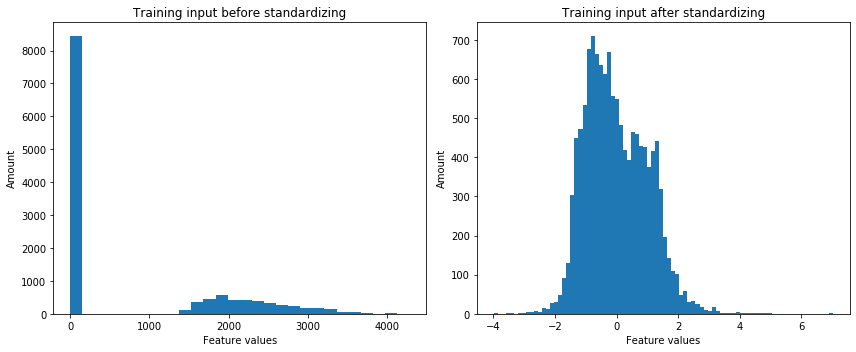

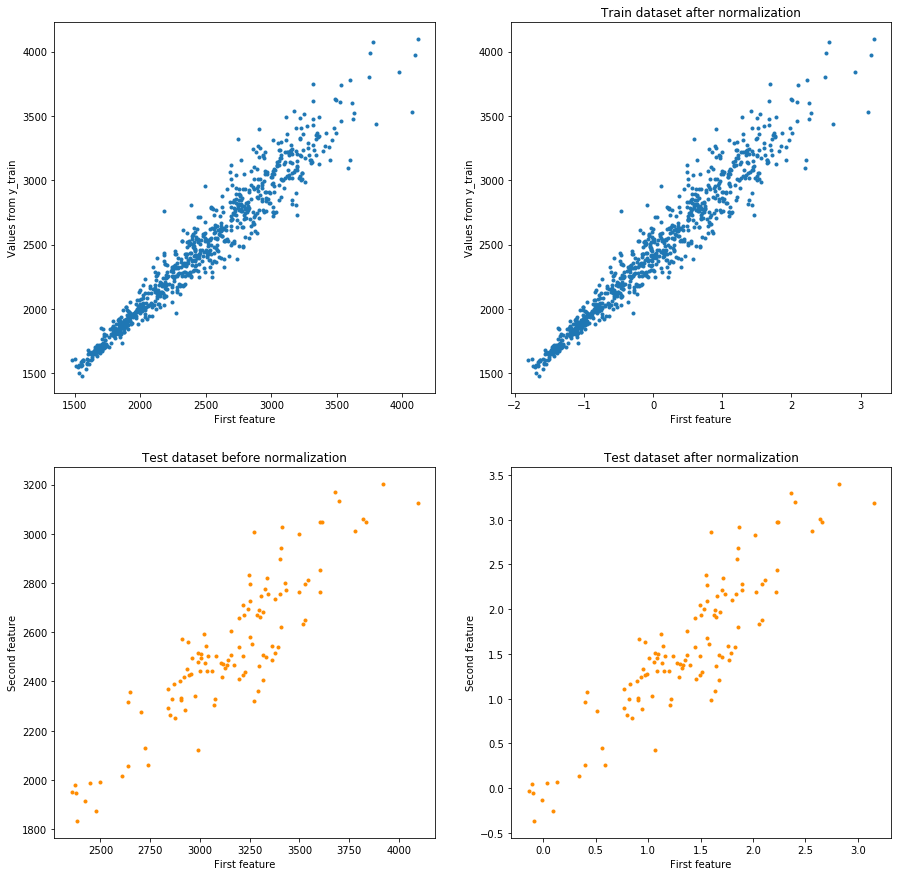

In [63]:
scaler = StandardScaler()
# fit on training data
scaler.fit(X_train)
# apply transformation to training data
X_train_scaled = scaler.transform(X_train)
# apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

fig1, ax1 = fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
ax1[0].hist(np.hstack(X_train), bins = 'auto')
ax1[0].set_title("Training input before standardizing")
ax1[0].set_xlabel("Feature values")
ax1[0].set_ylabel("Amount")
ax1[1].hist(np.hstack(X_train_scaled), bins = 'auto')
ax1[1].set_title("Training input after standardizing")
ax1[1].set_xlabel("Feature values")
ax1[1].set_ylabel("Amount")
plt.tight_layout()
#plt.savefig('/home/critical/Pictures/predictPowerConsumption_normalization')

## Plot before StandardScaler, for visualization of first and second components. TRAINING DATASET
fig2, ax2 = fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))
("Train dataset before normalization")
ax2[0,0].scatter(X_train[:, 0], y_train,marker=".")
ax2[0,0].set_xlabel("First feature")
ax2[0,0].set_ylabel("Values from y_train")
## Plot after StandardScaler, for visualization of first and second components.  TRAINING DATASET
ax2[0,1].set_title("Train dataset after normalization")
ax2[0,1].scatter(X_train_scaled[:, 0], y_train,marker=".")
ax2[0,1].set_xlabel("First feature")
ax2[0,1].set_ylabel("Values from y_train")

## Plot before StandardScaler, for visualization of first and second components. TEST DATASET
ax2[1,0].set_title("Test dataset before normalization")
ax2[1,0].scatter(X_test[:,0], X_test[:,1],marker=".", color="darkorange")
ax2[1,0].set_xlabel("First feature")
ax2[1,0].set_ylabel("Second feature")
## Plot after StandardScaler, for visualization of first and second components.  TEST DATASET
ax2[1,1].set_title("Test dataset after normalization")
ax2[1,1].scatter(X_test_scaled[:,0], X_test_scaled[:, 1],marker=".", color="darkorange")
ax2[1,1].set_xlabel("First feature")
_ = ax2[1,1].set_ylabel("Second feature")

## 3.3. Method and scoring
Here we choose different methods and tune the hyper-parameters with the help of <b>GridSearchCV</b>. After getting the parameters which gave us the best scoring we compare the algorithms to eachother to get the model that predicts the best. The scoring is based on MSE. CV is done 10-fold.

### 3.3.1. Baseline
Linear regression will be our baseline, the sklearn default will be used.

In [58]:
# Dictionary with parameters for MLPRegressor using GridSearchCV
tuned_parameters = [{}]

print("Training LinearRegression, this might take a while...")
lin_gscv = GridSearchCV( LinearRegression(),tuned_parameters, scoring='neg_mean_squared_error', n_jobs=-1, cv=10, verbose=2) # n_jobs=-1 uses all cores on the CPU.
lin_gscv.fit(X_train_scaled, y_train)

print("\nGridSearchCV found that these parameters are the best:\n")
lin_est = lin_gscv.best_estimator_

mean = lin_gscv.cv_results_['mean_test_score'][lin_gscv.best_index_]
std = lin_gscv.cv_results_['std_test_score'][lin_gscv.best_index_]
params = lin_gscv.cv_results_['params'][lin_gscv.best_index_]
print("%r\nMean: %0.3f. Std: %0.03f\n" % (params, mean, std))

Training LinearRegression, this might take a while...
Fitting 10 folds for each of 1 candidates, totalling 10 fits

GridSearchCV found that these parameters are the best:

{}
Mean: -6336.473. Std: 1415.581



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.1s finished


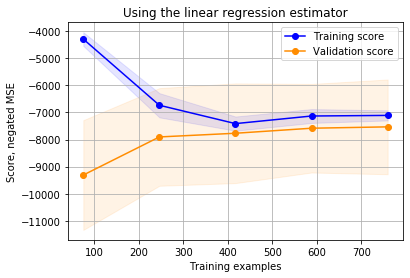

In [38]:
train_sizes, train_scores, test_scores = learning_curve(lin_est, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#print("%0.3f (+/- %0.03f)" % (test_scores_mean[-1], test_scores_std[-1]))

plt.title("Using the linear regression estimator")
plt.xlabel("Training examples")
plt.ylabel("Score, negated MSE")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="darkorange")
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="darkorange", label="Validation score")
plt.legend(loc="best")
plt.show()

### 3.3.2. MLPRegressor
The first method we choose is MLPRegressor

In [5]:
# Dictionary with parameters for MLPRegressor using GridSearchCV
tuned_parameters = [{'hidden_layer_sizes':[(10,7,5,3,2), (15,10,5,2), (5,5,3), (5,3), (20,), (50,), (15,10,5,3,2), (20,20,20,5,5,5,5,5)],
                     'activation':['logistic', 'relu'], 
                     'solver':['lbfgs', 'adam'],
                     'alpha':[10, 50, 100,250, 500, 750, 1000],
                     'learning_rate_init':[0.005, 0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1],
                     'max_iter':[2000] }]

print("Training MLPRegressor, this might take a while...")
mlpr_gscv = GridSearchCV( MLPRegressor(), tuned_parameters, scoring='neg_mean_squared_error', n_jobs=-1, cv=10, verbose=2) # n_jobs=-1 uses all cores on the CPU.
mlpr_gscv.fit(X_train_scaled, y_train)#X_train_pca_scaled, y_train)

print("\nGridSearchCV found that these parameters are the best:\n")
mlpr_est = mlpr_gscv.best_estimator_

mean = mlpr_gscv.cv_results_['mean_test_score'][mlpr_gscv.best_index_]
std = mlpr_gscv.cv_results_['std_test_score'][mlpr_gscv.best_index_]
params = mlpr_gscv.cv_results_['params'][mlpr_gscv.best_index_]
print("%r\nMean: %0.3f. Std: %0.03f\n" % (params, mean, std))

Training MLPRegressor, this might take a while...
Fitting 10 folds for each of 1792 candidates, totalling 17920 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   48.1s
[Parallel(n_jobs=-1)]: Done 166 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 369 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 652 tasks      | elapsed: 11.8min
[Parallel(n_jobs=-1)]: Done 1017 tasks      | elapsed: 17.2min
[Parallel(n_jobs=-1)]: Done 1462 tasks      | elapsed: 28.7min
[Parallel(n_jobs=-1)]: Done 1989 tasks      | elapsed: 37.3min
[Parallel(n_jobs=-1)]: Done 2596 tasks      | elapsed: 50.3min
[Parallel(n_jobs=-1)]: Done 3285 tasks      | elapsed: 62.3min
[Parallel(n_jobs=-1)]: Done 4054 tasks      | elapsed: 78.4min
[Parallel(n_jobs=-1)]: Done 4905 tasks      | elapsed: 90.9min
[Parallel(n_jobs=-1)]: Done 5836 tasks      | elapsed: 108.1min
[Parallel(n_jobs=-1)]: Done 6849 tasks      | elapsed: 127.4min
[Parallel(n_jobs=-1)]: Done 7942 tasks      | elapsed: 146.7min
[Parallel(n_jobs=-1)]: Done 9117 tasks     


GridSearchCV found that these parameters are the best:

{'activation': 'relu', 'alpha': 500, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.05, 'max_iter': 2000, 'solver': 'lbfgs'}
Mean: -3283.175. Std: 690.491



After receiving the best parameters for our MLPRegressor using GridSearchCV, we plot the y_training set and predictions made on X_test set to visualize if the predictions are withing reasonable constraints. We also plot y_train set together with prediction on the X_train set to visualize if the predictor is fitting perfectly on the training data or not. Only three of the features will be used to visualize.

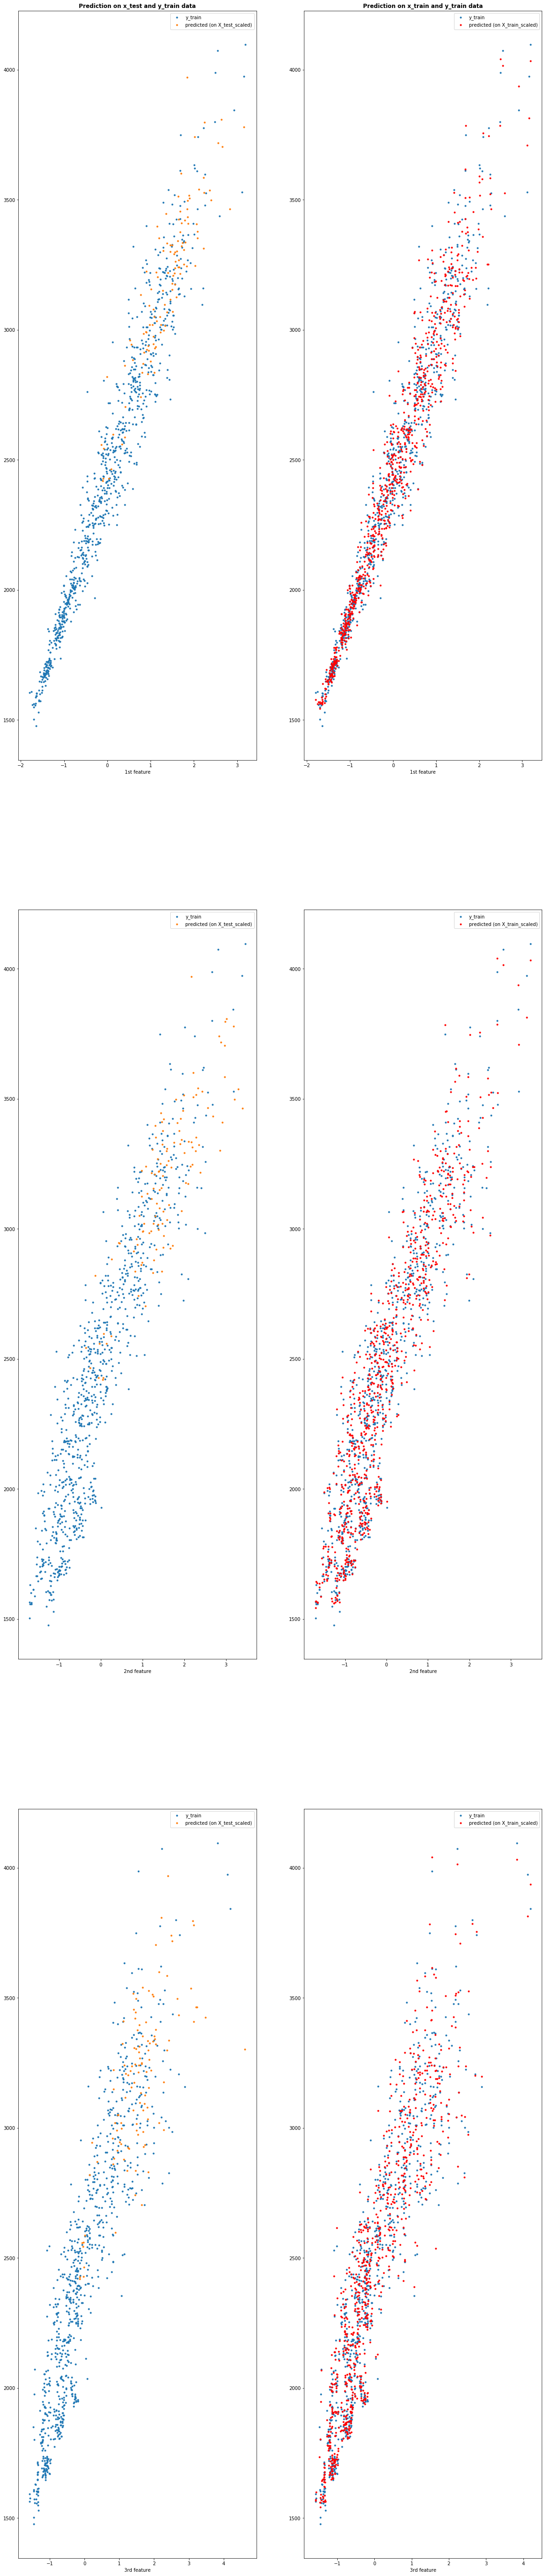

In [6]:
x_test_predicted = mlpr_est.predict(X_test_scaled)
x_train_predicted = mlpr_est.predict(X_train_scaled)

nrows=3
ncols=2
fig4, ax4 = fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 50))
ax4[0,0].scatter(X_train_scaled[:, 0], y_train, marker=".", label="y_train")
ax4[0,0].scatter(X_test_scaled[:, 0], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")

ax4[0,1].scatter(X_train_scaled[:, 0], y_train, marker=".", label="y_train")
ax4[0,1].scatter(X_train_scaled[:, 0], x_train_predicted, marker=".", color="red", label="predicted (on X_train_scaled)")

ax4[0,0].set_xlabel("1st feature")
ax4[0,1].set_xlabel("1st feature")

ax4[0,0].set_title("Prediction on x_test and y_train data", fontweight='bold')
ax4[0,1].set_title("Prediction on x_train and y_train data", fontweight='bold')

ax4[0,0].legend(loc="best")
ax4[0,1].legend(loc="best")

##################################################################################################################################################################
##########     Same method for the first 3 subplots and a for-loop for the rest (because of english grammar -> 1st, 2nd, 3rd, 4th ... 11th ... Xth)     ##########
##################################################################################################################################################################
ax4[1,0].scatter(X_train_scaled[:, 1], y_train, marker=".", label="y_train")
ax4[1,0].scatter(X_test_scaled[:, 1], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")
ax4[1,1].scatter(X_train_scaled[:, 1], y_train, marker=".", label="y_train")
ax4[1,1].scatter(X_train_scaled[:, 1], x_train_predicted, marker=".", color="red", label="predicted (on X_train_scaled)")
ax4[1,0].set_xlabel("2nd feature")
ax4[1,1].set_xlabel("2nd feature")
ax4[1,0].legend(loc="best")
ax4[1,1].legend(loc="best")
ax4[2,0].scatter(X_train_scaled[:, 2], y_train, marker=".", label="y_train")
ax4[2,0].scatter(X_test_scaled[:, 2], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")
ax4[2,1].scatter(X_train_scaled[:, 2], y_train, marker=".", label="y_train")
ax4[2,1].scatter(X_train_scaled[:, 2], x_train_predicted, marker=".", color="red", label="predicted (on X_train_scaled)")
ax4[2,0].set_xlabel("3rd feature")
ax4[2,1].set_xlabel("3rd feature")
ax4[2,0].legend(loc="best")
ax4[2,1].legend(loc="best")
for row in range(3, nrows):
    ax4[row,0].scatter(X_train_scaled[:, row], y_train, marker=".", label="y_train")
    ax4[row,0].scatter(X_test_scaled[:, row], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")

    ax4[row,1].scatter(X_train_scaled[:, row], y_train, marker=".", label="y_train")
    ax4[row,1].scatter(X_train_scaled[:, row], x_train_predicted, marker=".", color="red", label="predicted (on X_train_scaled)")

    ax4[row,0].set_xlabel(str(row+1) + "th feature")
    ax4[row,1].set_xlabel(str(row+1) + "th feature")
    
    ax4[row,0].legend(loc="best")
    ax4[row,1].legend(loc="best")

plt.show()

Here we plot learning curve to see if we overfit or underfit. As the training examples grow we see that we dont overfit or underfit. The model looks pretty good.

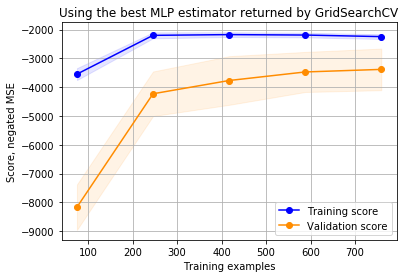

In [7]:
train_sizes, train_scores, test_scores = learning_curve(mlpr_est, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#print("%0.3f (+/- %0.03f)" % (test_scores_mean[-1], test_scores_std[-1]))

plt.title("Using the best MLP estimator returned by GridSearchCV")
plt.xlabel("Training examples")
plt.ylabel("Score, negated MSE")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="darkorange")
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="darkorange", label="Validation score")
plt.legend(loc="best")
plt.show()

### 3.3.3. Random Forest Regressor
The second method we choose is Random Forest Regressor. Same methodology on evaluation is applied as before

In [6]:
# Dictionary with parameters for RandomForestRegressor using GridSearchCV
tuned_parameters = [{'n_estimators':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25],
                     'criterion':['mse'], 
                     'min_samples_split':[0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                     'min_samples_leaf':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20, 25],
                     'n_jobs':[-1],
                     'max_samples':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9] }]

print("Training RandomForestRegressor, this might take a while...")
rfr_gscv = GridSearchCV( RandomForestRegressor(), tuned_parameters, scoring='neg_mean_squared_error', n_jobs=-1, cv=10, verbose=2) # n_jobs=-1 uses all cores on the CPU.
rfr_gscv.fit(X_train_scaled, y_train)

print("\nGridSearchCV found that these parametors are the best:\n")
rfr_est = rfr_gscv.best_estimator_

mean = rfr_gscv.cv_results_['mean_test_score'][rfr_gscv.best_index_]
std = rfr_gscv.cv_results_['std_test_score'][rfr_gscv.best_index_]
params = rfr_gscv.cv_results_['params'][rfr_gscv.best_index_]
print("%r\nMean: %0.3f. Std: %0.03f\n" % (params, mean, std))

Training RandomForestRegressor, this might take a while...
Fitting 10 folds for each of 26520 candidates, totalling 265200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 516 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 1328 tasks      | elapsed:   17.9s
[Parallel(n_jobs=-1)]: Done 2460 tasks      | elapsed:   32.9s
[Parallel(n_jobs=-1)]: Done 3920 tasks      | elapsed:   50.6s
[Parallel(n_jobs=-1)]: Done 5700 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 7808 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 10236 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 12992 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 16068 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 19472 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 23196 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 27248 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 31620 tasks      | elapsed:  6.3min
[Parallel(n_jobs=-1)]: Done 36804 tas


GridSearchCV found that these parametors are the best:

{'criterion': 'mse', 'max_samples': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 0.005, 'n_estimators': 25, 'n_jobs': -1}
Mean: -7915.719. Std: 1499.205



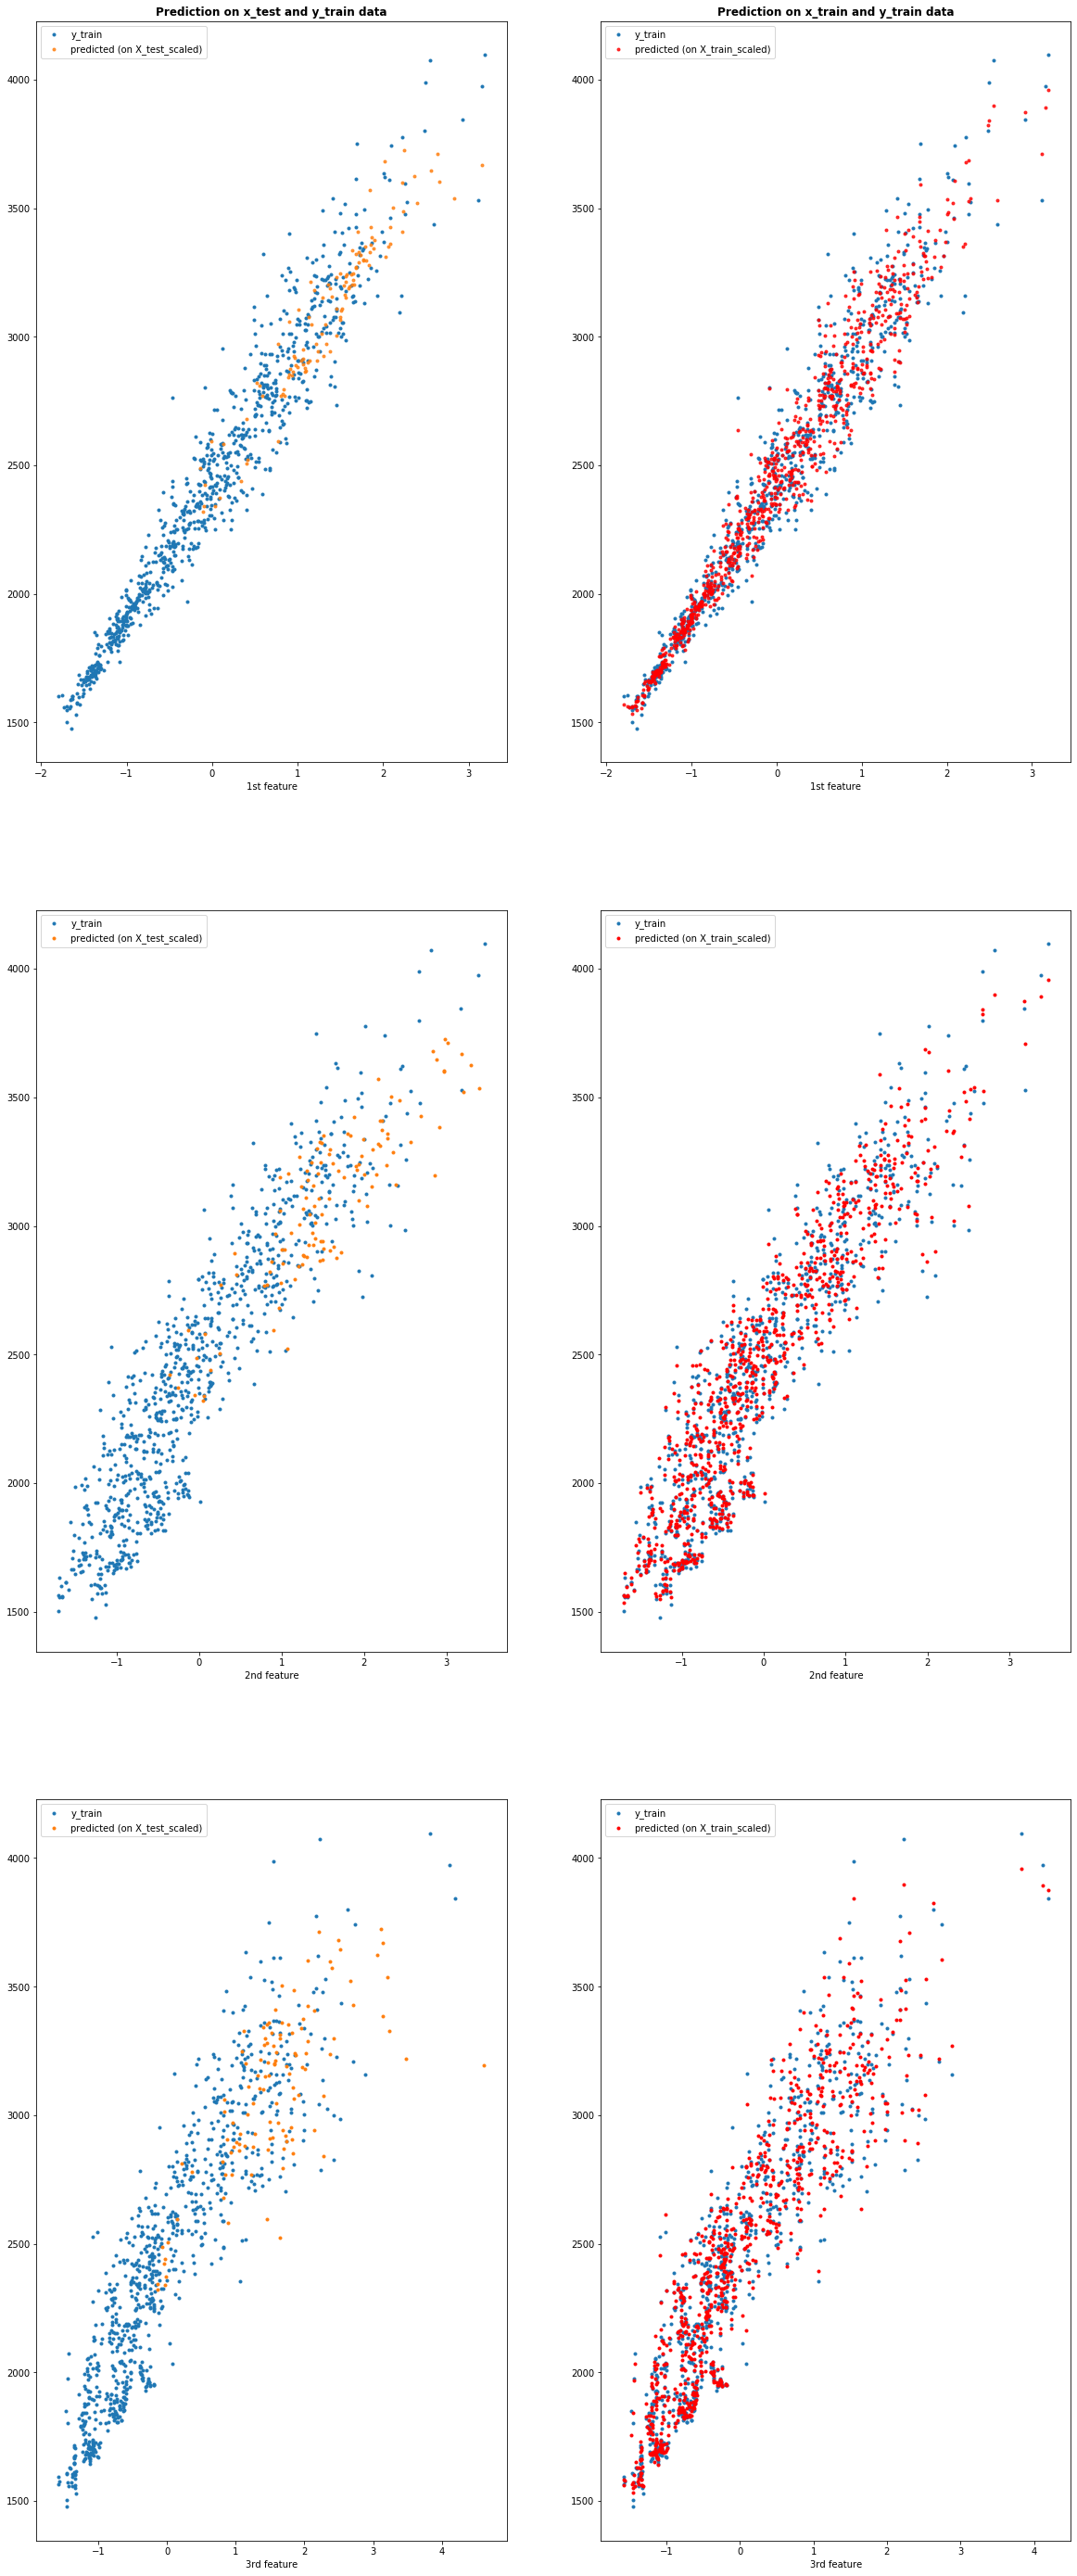

In [7]:
x_test_predicted = rfr_est.predict(X_test_scaled)
x_train_predicted = rfr_est.predict(X_train_scaled)

nrows=3
ncols=2
fig4, ax4 = fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 50))
ax4[0,0].scatter(X_train_scaled[:, 0], y_train, marker=".", label="y_train")
ax4[0,0].scatter(X_test_scaled[:, 0], x_test_predicted, marker=".", alpha=0.8, label="predicted (on X_test_scaled)")

ax4[0,1].scatter(X_train_scaled[:, 0], y_train, marker=".", label="y_train")
ax4[0,1].scatter(X_train_scaled[:, 0], x_train_predicted, marker=".", color="red", alpha=0.8, label="predicted (on X_train_scaled)")

ax4[0,0].set_xlabel("1st feature")
ax4[0,1].set_xlabel("1st feature")

ax4[0,0].set_title("Prediction on x_test and y_train data", fontweight='bold')
ax4[0,1].set_title("Prediction on x_train and y_train data", fontweight='bold')

ax4[0,0].legend(loc="best")
ax4[0,1].legend(loc="best")

##################################################################################################################################################################
##########     Same method for the first 3 subplots and a for-loop for the rest (because of english grammar -> 1st, 2nd, 3rd, 4th ... 11th ... Xth)     ##########
##################################################################################################################################################################
ax4[1,0].scatter(X_train_scaled[:, 1], y_train, marker=".", label="y_train")
ax4[1,0].scatter(X_test_scaled[:, 1], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")
ax4[1,1].scatter(X_train_scaled[:, 1], y_train, marker=".", label="y_train")
ax4[1,1].scatter(X_train_scaled[:, 1], x_train_predicted, marker=".", color="red", label="predicted (on X_train_scaled)")
ax4[1,0].set_xlabel("2nd feature")
ax4[1,1].set_xlabel("2nd feature")
ax4[1,0].legend(loc="best")
ax4[1,1].legend(loc="best")
ax4[2,0].scatter(X_train_scaled[:, 2], y_train, marker=".", label="y_train")
ax4[2,0].scatter(X_test_scaled[:, 2], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")
ax4[2,1].scatter(X_train_scaled[:, 2], y_train, marker=".", label="y_train")
ax4[2,1].scatter(X_train_scaled[:, 2], x_train_predicted, marker=".", color="red", label="predicted (on X_train_scaled)")
ax4[2,0].set_xlabel("3rd feature")
ax4[2,1].set_xlabel("3rd feature")
ax4[2,0].legend(loc="best")
ax4[2,1].legend(loc="best")
for row in range(3, nrows):
    ax4[row,0].scatter(X_train_scaled[:, row], y_train, marker=".", label="y_train")
    ax4[row,0].scatter(X_test_scaled[:, row], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")

    ax4[row,1].scatter(X_train_scaled[:, row], y_train, marker=".", label="y_train")
    ax4[row,1].scatter(X_train_scaled[:, row], x_train_predicted, marker=".", color="red", label="predicted (on X_train_scaled)")

    ax4[row,0].set_xlabel(str(row+1) + "th feature")
    ax4[row,1].set_xlabel(str(row+1) + "th feature")
    
    ax4[row,0].legend(loc="best")
    ax4[row,1].legend(loc="best")

plt.show()

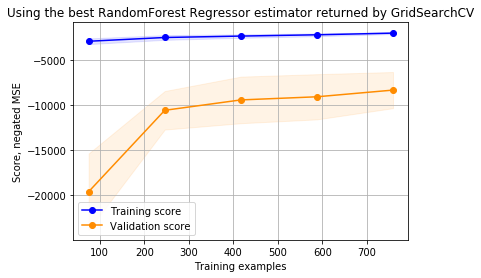

In [8]:
train_sizes, train_scores, test_scores = learning_curve(rfr_est, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#print("%0.3f (+/- %0.03f)" % (test_scores_mean[-1], test_scores_std[-1]))

plt.title("Using the best RandomForest Regressor estimator returned by GridSearchCV")
plt.xlabel("Training examples")
plt.ylabel("Score, negated MSE")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="darkorange")
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="darkorange", label="Validation score")
plt.legend(loc="best")
plt.show()

### 3.3.4. kNN regressor
The third method we choose is kNN Regressor. Same methodology on evaluation is applied as previous.

In [9]:
# Dictionary with parameters for RandomForestRegressor using GridSearchCV
tuned_parameters = [{'n_neighbors':[i for i in range(20)],
                     'weights':['uniform', 'distance'],
                     'algorithm': ['kd_tree', 'ball_tree', 'brute'],
                     'leaf_size':[1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
                     #'p':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                     'metric':['wminkowski'],
                     'metric_params':[{'p':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'w':[2e-1, 1e-1, 1e+0, 5e+0, 1e+1, 2e+1]}],
                     'n_jobs':[-1]},
                    {'n_neighbors':[i for i in range(20)],
                     'weights':['uniform', 'distance'],
                     'algorithm': ['kd_tree', 'ball_tree', 'brute'],
                     'leaf_size':[2, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
                     'p':[2, 5, 7, 10, 15, 20, 25, 30, 35, 40, 45, 40],
                     'metric':['chebyshev', 'minkowski'],
                     'n_jobs':[-1] }]

print("Training kNN Regressor, this might take a while...")
kNN_gscv = GridSearchCV( KNeighborsRegressor(), tuned_parameters, scoring='neg_mean_squared_error', n_jobs=-1, cv=10, verbose=2) # n_jobs=-1 uses all cores on the CPU.
kNN_gscv.fit(X_train_scaled, y_train)

print("\nGridSearchCV found that these parametors are the best:\n")
kNN_est = kNN_gscv.best_estimator_

mean = kNN_gscv.cv_results_['mean_test_score'][kNN_gscv.best_index_]
std = kNN_gscv.cv_results_['std_test_score'][kNN_gscv.best_index_]
params = kNN_gscv.cv_results_['params'][kNN_gscv.best_index_]
print("%r\nMean: %0.3f. Std: %0.03f\n" % (params, mean, std))

Training kNN Regressor, this might take a while...
Fitting 10 folds for each of 36240 candidates, totalling 362400 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 20572 tasks      | elapsed:   18.5s
[Parallel(n_jobs=-1)]: Done 25768 tasks      | elapsed:   43.9s
[Parallel(n_jobs=-1)]: Done 34824 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 46504 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 60744 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 77608 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done 91336 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 103356 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 118880 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 134832 tasks      | elapsed:  9.3min
[Parallel(n_jobs=-1)]: Done 147472 tasks      | elapsed: 10.8min
[Parallel(n_jobs=-1)]: Done 153136 tasks      | elapsed: 11.7min
[Parallel(n_jobs=-1)]: Done 167196 tasks      | elapsed: 13.5min
[Parallel(n_jobs=-1)]: D


GridSearchCV found that these parametors are the best:

{'algorithm': 'brute', 'leaf_size': 2, 'metric': 'minkowski', 'n_jobs': -1, 'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
Mean: -10239.861. Std: 2204.660



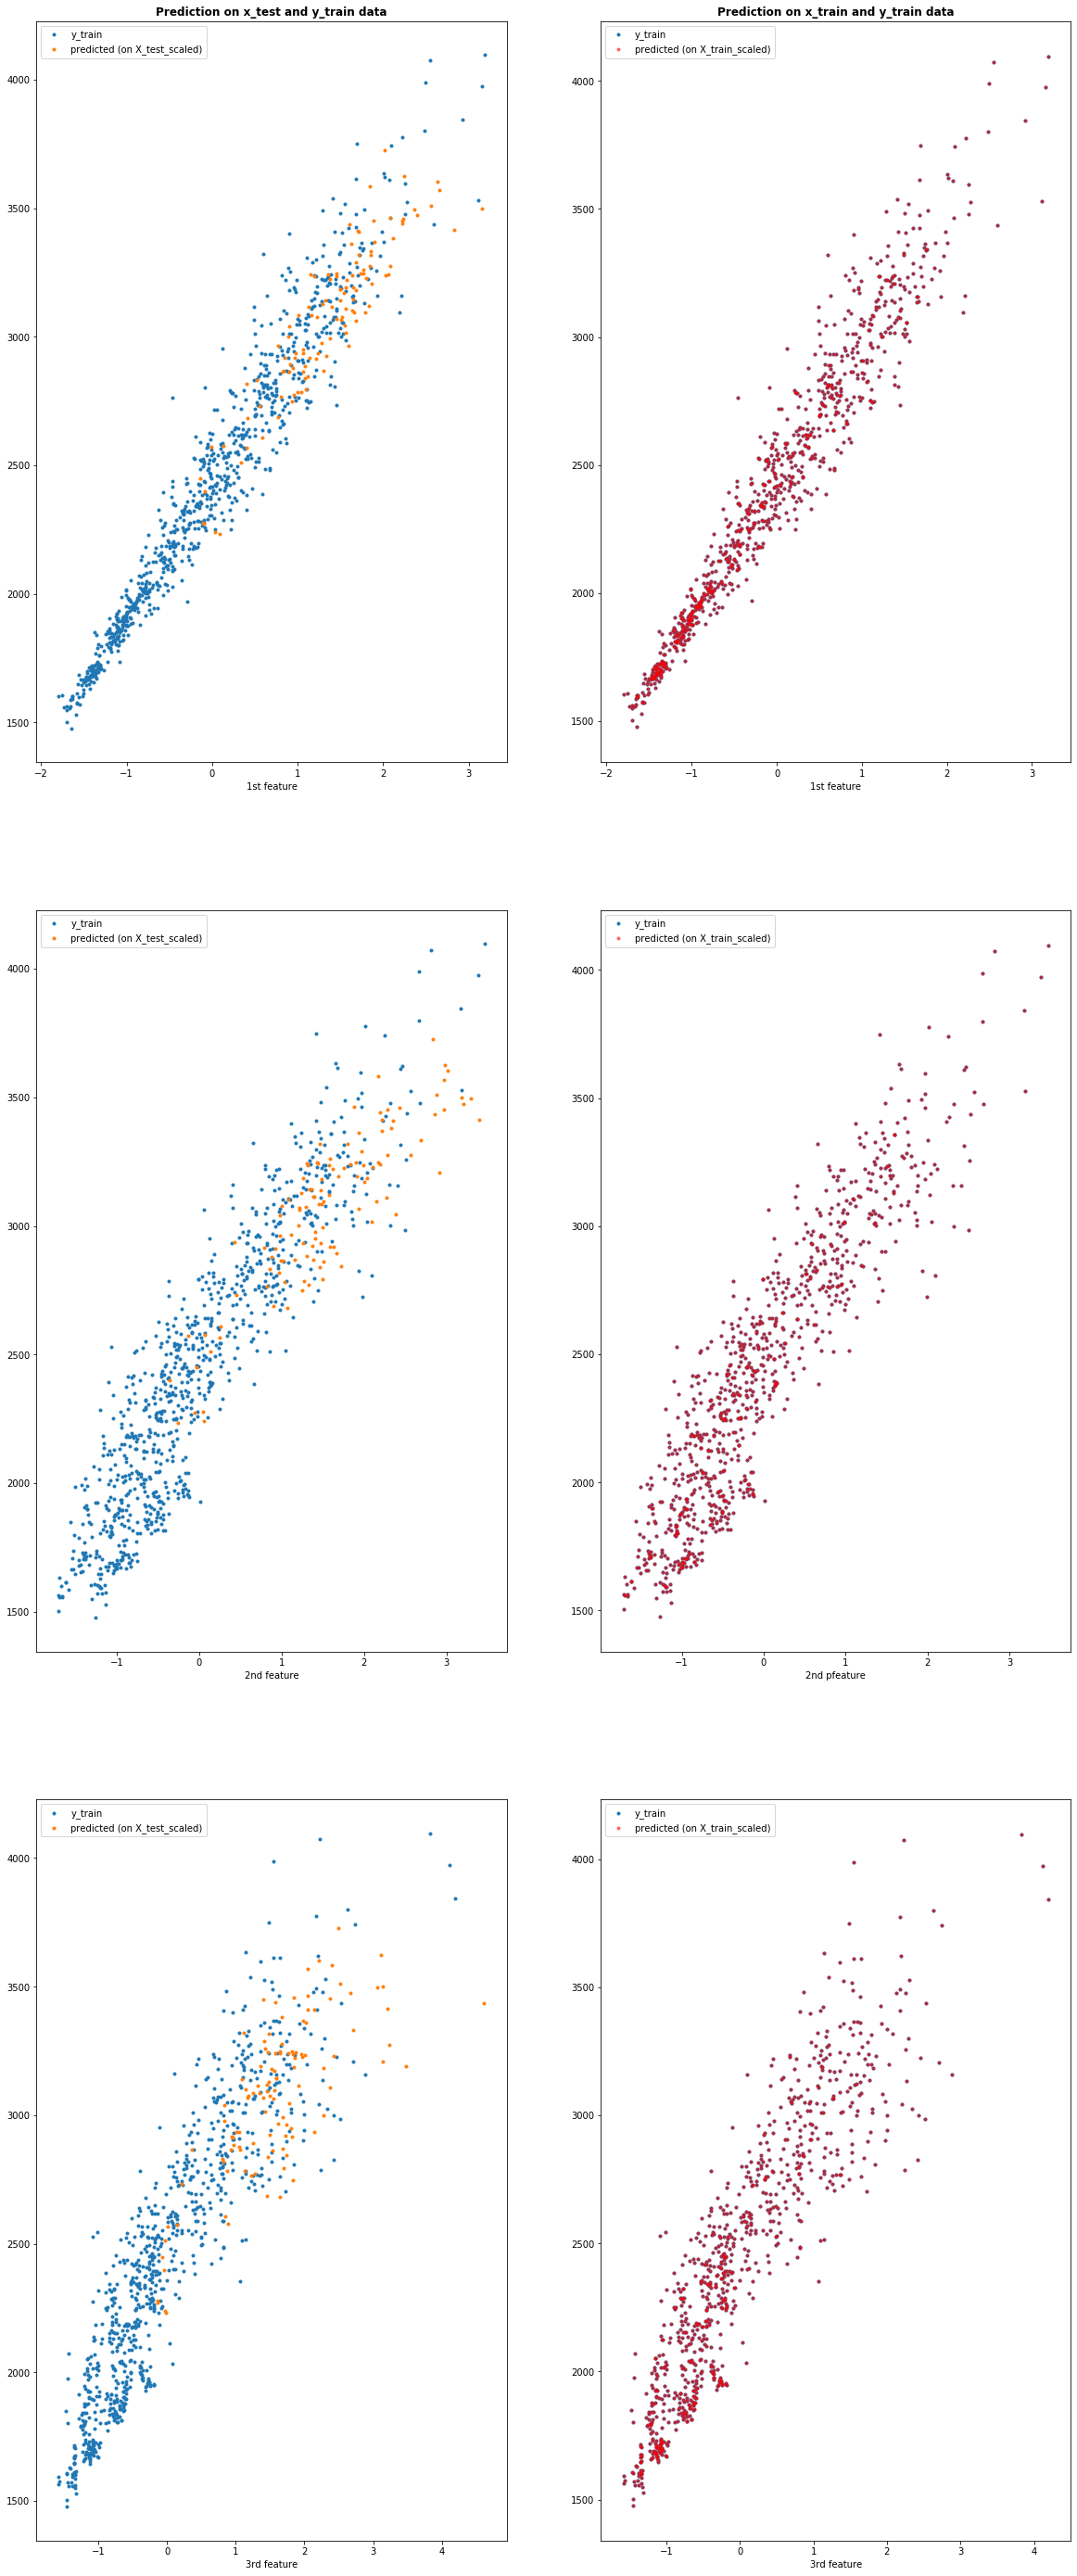

In [10]:
x_test_predicted = kNN_est.predict(X_test_scaled)
x_train_predicted = kNN_est.predict(X_train_scaled)

nrows=3
ncols=2
fig4, ax4 = fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 50))
ax4[0,0].scatter(X_train_scaled[:, 0], y_train, marker=".", label="y_train")
ax4[0,0].scatter(X_test_scaled[:, 0], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")

ax4[0,1].scatter(X_train_scaled[:, 0], y_train, marker=".", label="y_train")
ax4[0,1].scatter(X_train_scaled[:, 0], x_train_predicted, marker=".", color="red", alpha=0.5, label="predicted (on X_train_scaled)")

ax4[0,0].set_xlabel("1st feature")
ax4[0,1].set_xlabel("1st feature")

ax4[0,0].set_title("Prediction on x_test and y_train data", fontweight='bold')
ax4[0,1].set_title("Prediction on x_train and y_train data", fontweight='bold')

ax4[0,0].legend(loc="best")
ax4[0,1].legend(loc="best")

##################################################################################################################################################################
##########     Same method for the first 3 subplots and a for-loop for the rest (because of english grammar -> 1st, 2nd, 3rd, 4th ... 11th ... Xth)     ##########
##################################################################################################################################################################
ax4[1,0].scatter(X_train_scaled[:, 1], y_train, marker=".", label="y_train")
ax4[1,0].scatter(X_test_scaled[:, 1], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")
ax4[1,1].scatter(X_train_scaled[:, 1], y_train, marker=".", label="y_train")
ax4[1,1].scatter(X_train_scaled[:, 1], x_train_predicted, marker=".", color="red", alpha=0.5, label="predicted (on X_train_scaled)")
ax4[1,0].set_xlabel("2nd feature")
ax4[1,1].set_xlabel("2nd pfeature")
ax4[1,0].legend(loc="best")
ax4[1,1].legend(loc="best")
ax4[2,0].scatter(X_train_scaled[:, 2], y_train, marker=".", label="y_train")
ax4[2,0].scatter(X_test_scaled[:, 2], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")
ax4[2,1].scatter(X_train_scaled[:, 2], y_train, marker=".", label="y_train")
ax4[2,1].scatter(X_train_scaled[:, 2], x_train_predicted, marker=".", color="red", alpha=0.5, label="predicted (on X_train_scaled)")
ax4[2,0].set_xlabel("3rd feature")
ax4[2,1].set_xlabel("3rd feature")
ax4[2,0].legend(loc="best")
ax4[2,1].legend(loc="best")
for row in range(3, nrows):
    ax4[row,0].scatter(X_train_scaled[:, row], y_train, marker=".", label="y_train")
    ax4[row,0].scatter(X_test_scaled[:, row], x_test_predicted, marker=".", label="predicted (on X_test_scaled)")

    ax4[row,1].scatter(X_train_scaled[:, row], y_train, marker=".", label="y_train")
    ax4[row,1].scatter(X_train_scaled[:, row], x_train_predicted, marker=".", color="red", alpha=0.5, label="predicted (on X_train_scaled)")

    ax4[row,0].set_xlabel(str(row+1) + "th feature")
    ax4[row,1].set_xlabel(str(row+1) + "th feature")
    
    ax4[row,0].legend(loc="best")
    ax4[row,1].legend(loc="best")

plt.show()

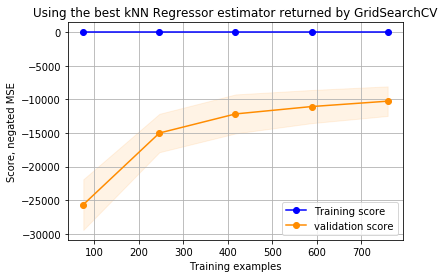

In [11]:
train_sizes, train_scores, test_scores = learning_curve(kNN_est, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#print("%0.3f (+/- %0.03f)" % (test_scores_mean[-1], test_scores_std[-1]))

plt.title("Using the best kNN Regressor estimator returned by GridSearchCV")
plt.xlabel("Training examples")
plt.ylabel("Score, negated MSE")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="darkorange")
plt.plot(train_sizes, train_scores_mean, 'o-', color="b", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="darkorange", label="validation score")
plt.legend(loc="best")
plt.show()

## 2.4. Evaluation of results

As we can see the best result is from MLPRegression, the other two models are performing worse than the baseline. We have therefore chosen to predict X_test with the best MLPRegressor. The predictions have been saved to a mat-file called <b>powerConsumptionPredictions.mat.mat</b> and are labeled predictions.

In [19]:
mlpr_est = MLPRegressor(activation='relu', alpha=500, hidden_layer_sizes=(50,), learning_rate_init=0.05, max_iter= 2000, solver= 'lbfgs').fit(X_train_scaled, y_train)
predictions = mlpr_est.predict(X_test_scaled)
savemat('powerConsumptionPredictions.mat', {'predictions':predictions})
print(predictions)

[3323.92698982 3303.60748872 3601.25132272 3143.14000356 2940.79652441
 2584.24924707 2579.67416814 3388.20621313 3285.50826453 3470.62293677
 3267.58110531 3352.27214809 3108.25562194 2835.26340316 2586.78358846
 3205.06450686 3319.43417844 3249.19330744 2938.61322189 3408.29061121
 2812.1117729  3261.22206759 3241.65788291 3495.86564341 3188.22247325
 3388.17084012 3588.83377368 2424.6814403  3208.13548919 3323.42554306
 3709.8771946  2955.79439101 3247.61440179 3764.7572686  3505.99863707
 3327.76221806 3521.3470659  2938.93184505 3280.04429557 3041.91423141
 2691.04257447 3541.40836599 3220.5368918  3529.57874184 3540.49576979
 3023.91534851 2540.76093209 2872.29585239 2894.33937085 2432.25509724
 3154.61011441 3457.75173281 3311.86367704 2557.19989881 3053.08050988
 3330.43460251 2889.61016818 3361.59684872 3342.86076668 3282.53765005
 3261.20725657 3741.04647589 3243.78127906 3316.88412207 3752.70442649
 3498.57566969 3455.37352621 3237.23685649 3036.44281187 3547.24048369
 2846.